<a href="https://colab.research.google.com/github/emilheroyt/Bachelor-Thesis-Stress-Testing-Robustness-of-SOTA-Point-Trackers/blob/main/results_experiment1and2/All3CSVsUpdated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Zelle 1 – Daten laden (die vollständigsten Versionen pro Modell):

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

base = "/content/drive/MyDrive/ba_results/"
df = pd.concat([
    pd.read_csv(base + "cotracker3_all_videos_v2.csv"),
    pd.read_csv(base + "tapnext_all_videos_v2.csv"),
    pd.read_csv(base + "cowtracker_all_videos.csv"),
], ignore_index=True)

metrics = ["average_jaccard", "occlusion_accuracy", "average_pts_within_thresh"]
blur_order = ["none", "medium", "strong"]
models = ["CoTracker3", "TapNext", "CoWTracker"]
print(df.groupby("model").size())  # sollte 90 pro Modell zeigen (30 Videos × 3 Stufen)

Mounted at /content/drive
model
CoTracker3    90
CoWTracker    90
TapNext       90
dtype: int64


Zelle 2 – Mittelwert, Standardabweichung, 95 %-Konfidenzintervall:

In [2]:
def summarize(g):
    n = len(g)
    return pd.Series({
        "mean": g.mean(),
        "std": g.std(ddof=1),
        "ci95": 1.96 * g.std(ddof=1) / np.sqrt(n),
        "n": n,
    })

rows = []
for metric in metrics:
    s = df.groupby(["model", "blur"])[metric].apply(summarize).unstack()
    s["metric"] = metric
    rows.append(s.reset_index())
stats_table = pd.concat(rows).set_index(["metric", "model", "blur"]).round(2)
print(stats_table)
stats_table.to_csv(base + "experiment1_stats_mean_std_ci.csv")

                                              mean    std  ci95     n
metric                    model      blur                            
average_jaccard           CoTracker3 medium  46.86  21.73  7.78  30.0
                                     none    62.56  16.75  5.99  30.0
                                     strong  25.95  19.64  7.03  30.0
                          CoWTracker medium  48.24  16.00  5.72  30.0
                                     none    56.90  14.58  5.22  30.0
                                     strong  33.97  16.82  6.02  30.0
                          TapNext    medium  42.32  23.56  8.43  30.0
                                     none    66.71  14.82  5.30  30.0
                                     strong  19.22  16.30  5.83  30.0
occlusion_accuracy        CoTracker3 medium  80.38  16.15  5.78  30.0
                                     none    88.13   9.98  3.57  30.0
                                     strong  66.90  20.94  7.49  30.0
                    

Zelle 3 – Relative Degradation pro Video:

In [3]:
wide = df.pivot_table(index=["model", "video"], columns="blur", values="average_jaccard")
for level in ["medium", "strong"]:
    wide[f"rel_drop_{level}"] = (wide["none"] - wide[level]) / wide["none"] * 100

rel = wide.reset_index().groupby("model")[["rel_drop_medium", "rel_drop_strong"]].apply(
    lambda g: pd.DataFrame({"mean": g.mean(), "ci95": 1.96 * g.std(ddof=1) / np.sqrt(len(g))})
).round(1)
print(rel)
rel.to_csv(base + "experiment1_relative_degradation.csv")

                            mean  ci95
model      blur                       
CoTracker3 rel_drop_medium  27.7   8.2
           rel_drop_strong  60.0   9.4
CoWTracker rel_drop_medium  15.6   5.4
           rel_drop_strong  40.6   8.2
TapNext    rel_drop_medium  39.2   9.7
           rel_drop_strong  72.3   7.6


Zelle 4 – Gepaarter Vergleich (gleiche 30 Videos) am Kreuzungspunkt:

In [4]:
from scipy.stats import wilcoxon

def paired_compare(model_a, model_b, level, metric="average_jaccard"):
    a = df[(df.model == model_a) & (df.blur == level)].set_index("video")[metric]
    b = df[(df.model == model_b) & (df.blur == level)].set_index("video")[metric]
    d = (a - b).dropna()
    stat, p = wilcoxon(d)
    print(f"{level}: {model_a} − {model_b} = {d.mean():.1f} ± {1.96*d.std(ddof=1)/np.sqrt(len(d)):.1f} "
          f"| {model_a} besser in {(d > 0).sum()}/{len(d)} Videos | Wilcoxon p = {p:.4f}")

for level in blur_order:
    paired_compare("TapNext", "CoWTracker", level)
print()
for level in blur_order:
    paired_compare("TapNext", "CoTracker3", level)

none: TapNext − CoWTracker = 9.8 ± 2.8 | TapNext besser in 26/30 Videos | Wilcoxon p = 0.0000
medium: TapNext − CoWTracker = -5.9 ± 5.3 | TapNext besser in 11/30 Videos | Wilcoxon p = 0.0497
strong: TapNext − CoWTracker = -14.8 ± 4.2 | TapNext besser in 3/30 Videos | Wilcoxon p = 0.0000

none: TapNext − CoTracker3 = 4.1 ± 2.0 | TapNext besser in 23/30 Videos | Wilcoxon p = 0.0007
medium: TapNext − CoTracker3 = -4.5 ± 4.2 | TapNext besser in 10/30 Videos | Wilcoxon p = 0.0449
strong: TapNext − CoTracker3 = -6.7 ± 3.0 | TapNext besser in 5/30 Videos | Wilcoxon p = 0.0000


Zelle 5 – Plot mit Fehlerbalken (ersetzt deinen bisherigen Exp.-1-Plot):

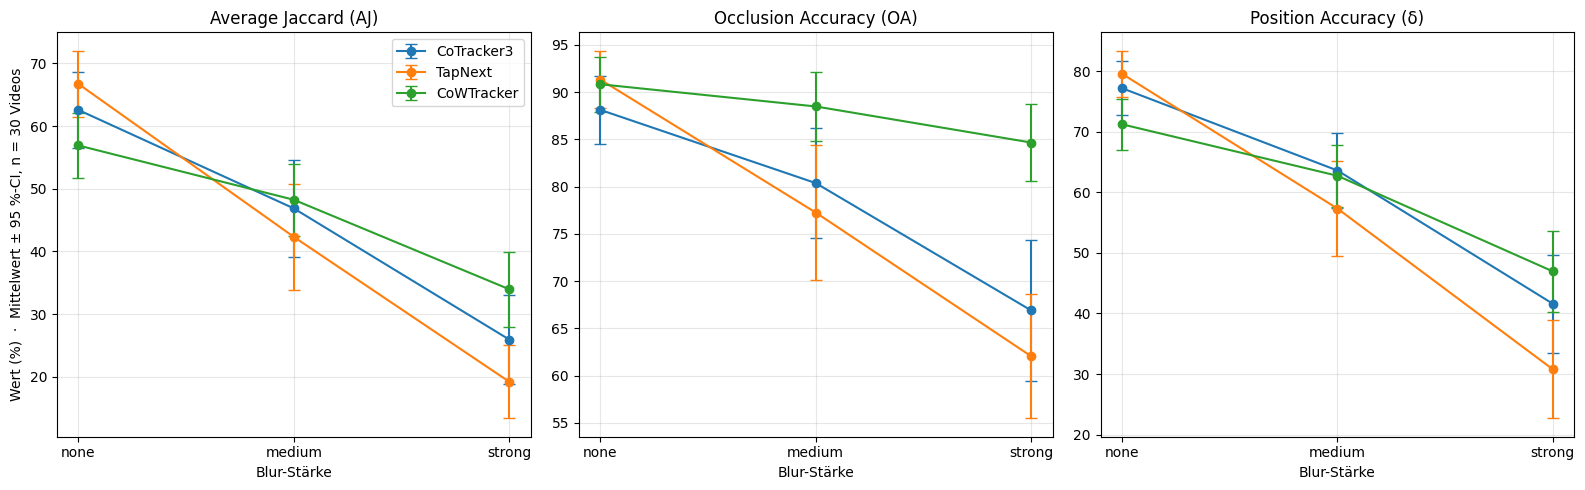

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ["Average Jaccard (AJ)", "Occlusion Accuracy (OA)", "Position Accuracy (δ)"]
for ax, metric, title in zip(axes, metrics, titles):
    for m in models:
        sub = stats_table.loc[metric].loc[m].reindex(blur_order)
        ax.errorbar(blur_order, sub["mean"], yerr=sub["ci95"], marker="o", capsize=4, label=m)
    ax.set_title(title); ax.set_xlabel("Blur-Stärke"); ax.grid(alpha=0.3)
axes[0].set_ylabel("Wert (%)  ·  Mittelwert ± 95 %-CI, n = 30 Videos"); axes[0].legend()
plt.tight_layout()
plt.savefig(base + "experiment1_all_metrics_with_ci.png", dpi=150)
plt.show()

Zelle 6 – Per-Video-Verteilung (zeigt, dass der Effekt nicht von 2–3 Ausreißer-Videos getragen wird):

/tmp/ipykernel_10717/2785857184.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=models, showmeans=True)
/tmp/ipykernel_10717/2785857184.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=models, showmeans=True)
/tmp/ipykernel_10717/2785857184.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=models, showmeans=True)


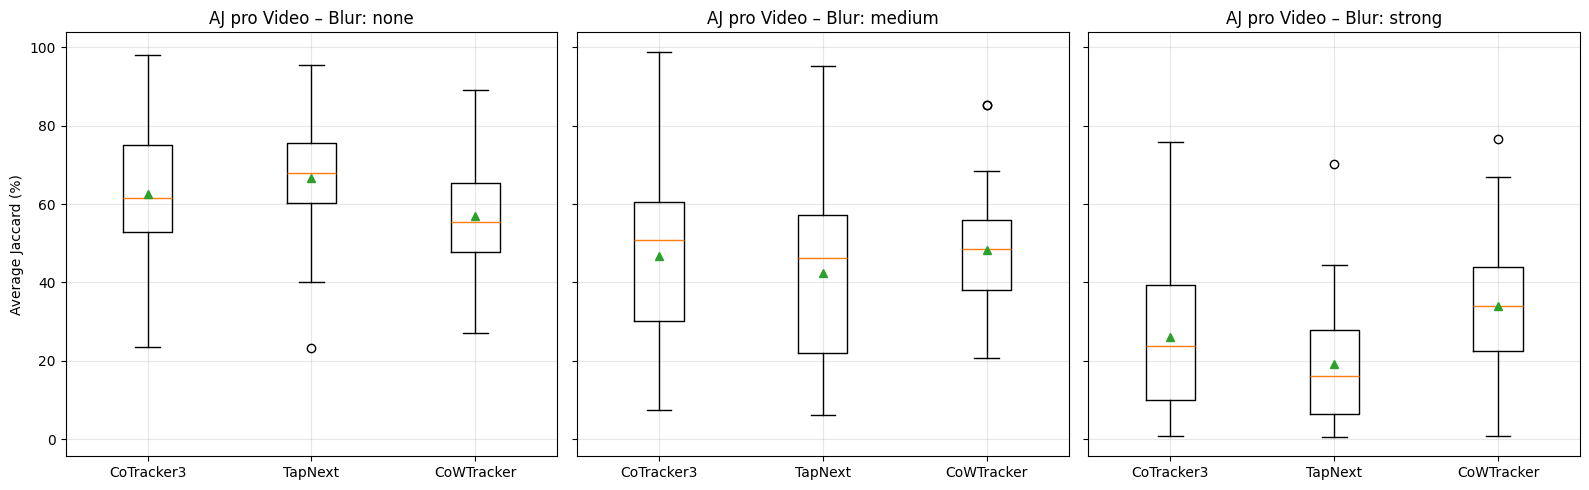

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, level in zip(axes, blur_order):
    data = [df[(df.model == m) & (df.blur == level)]["average_jaccard"].values for m in models]
    ax.boxplot(data, labels=models, showmeans=True)
    ax.set_title(f"AJ pro Video – Blur: {level}"); ax.grid(alpha=0.3)
axes[0].set_ylabel("Average Jaccard (%)")
plt.tight_layout()
plt.savefig(base + "experiment1_per_video_boxplots.png", dpi=150)
plt.show()

gepaarter Wilcoxon-Test auf den Per-Video-Verlusten rel_drop_medium/rel_drop_strong:

In [7]:
wide_r = wide.reset_index()
for level in ["medium", "strong"]:
    col = f"rel_drop_{level}"
    for a, b in [("TapNext", "CoTracker3"), ("TapNext", "CoWTracker"), ("CoTracker3", "CoWTracker")]:
        da = wide_r[wide_r.model == a].set_index("video")[col]
        db = wide_r[wide_r.model == b].set_index("video")[col]
        d = (da - db).dropna()
        p = wilcoxon(d).pvalue
        print(f"{level}: rel. Verlust {a} − {b} = {d.mean():.1f} Pp | p = {p:.4f}")

medium: rel. Verlust TapNext − CoTracker3 = 11.5 Pp | p = 0.0001
medium: rel. Verlust TapNext − CoWTracker = 23.6 Pp | p = 0.0000
medium: rel. Verlust CoTracker3 − CoWTracker = 12.1 Pp | p = 0.0001
strong: rel. Verlust TapNext − CoTracker3 = 12.3 Pp | p = 0.0000
strong: rel. Verlust TapNext − CoWTracker = 31.7 Pp | p = 0.0000
strong: rel. Verlust CoTracker3 − CoWTracker = 19.3 Pp | p = 0.0000
